### Graficas o insights para Género, Núcleo (área académica) y Nivel de Formación

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sbn
import numpy as np

In [2]:
# cargamos el dataset
ROOT = Path('..').resolve()
sex_programa = pd.read_csv(ROOT/'sex_programa.csv', sep=';')
display(sex_programa.head())

,SEXO,NUCLEO,NIVEL_FORMACION,TIPO,1998-1,1998-2,1999-1,1999-2,2000-1,2000-2,...,2020-1,2020-2,2021-1,2021-2,2022-1,2022-2,2023-1,2023-2,2024-1,2024-2
0,Mujer,Sin informaci¿n,Sin informaci¿n,DESERTORES,0.0,0.0,174.0,217.0,180.0,148.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Mujer,Sin informaci¿n,UNIVERSITARIA,DESERTORES,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,6.0
2,Mujer,Sin informaci¿n,TECNOLOGICA,DESERTORES,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,Mujer,Sin informaci¿n,FORMACION TECNICA PROFESIONAL,DESERTORES,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,Mujer,AGRONOMIA,UNIVERSITARIA,DESERTORES,0.0,0.0,6.0,15.0,21.0,23.0,...,310.0,404.0,368.0,330.0,389.0,410.0,522.0,523.0,754.0,714.0


In [3]:
# Exploramos las columnas y datos que tenemos así como su tipo
display(sex_programa.info())
display(sex_programa['SEXO'].value_counts())
display(sex_programa['NIVEL_FORMACION'].value_counts())
print('Núcleos únicos:', sex_programa['NUCLEO'].nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 848 entries, 0 to 847
Data columns (total 58 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   SEXO             848 non-null    object 
 1   NUCLEO           848 non-null    object 
 2   NIVEL_FORMACION  848 non-null    object 
 3   TIPO             848 non-null    object 
 4   1998-1           554 non-null    float64
 5   1998-2           534 non-null    float64
 6   1999-1           558 non-null    float64
 7   1999-2           558 non-null    float64
 8   2000-1           590 non-null    float64
 9   2000-2           588 non-null    float64
 10  2001-1           612 non-null    float64
 11  2001-2           618 non-null    float64
 12  2002-1           634 non-null    float64
 13  2002-2           630 non-null    float64
 14  2003-1           634 non-null    float64
 15  2003-2           636 non-null    float64
 16  2004-1           630 non-null    float64
 17  2004-2          

None

SEXO
Mujer              326
Hombre             326
Sin informaci¿n    196
Name: count, dtype: int64

NIVEL_FORMACION
UNIVERSITARIA                    328
TECNOLOGICA                      262
FORMACION TECNICA PROFESIONAL    240
ESPECIALIZACION                   12
Sin informaci¿n                    6
Name: count, dtype: int64

Núcleos únicos: 57


A priori podemos suprimir los valores de sin información en el campo del sexo

In [4]:
valores_sin_informacion_sexo = sex_programa[sex_programa['SEXO'] != 'Sin informaci¿n'].reset_index(drop=True)
display(valores_sin_informacion_sexo.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 652 entries, 0 to 651
Data columns (total 58 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   SEXO             652 non-null    object 
 1   NUCLEO           652 non-null    object 
 2   NIVEL_FORMACION  652 non-null    object 
 3   TIPO             652 non-null    object 
 4   1998-1           454 non-null    float64
 5   1998-2           440 non-null    float64
 6   1999-1           452 non-null    float64
 7   1999-2           450 non-null    float64
 8   2000-1           476 non-null    float64
 9   2000-2           486 non-null    float64
 10  2001-1           496 non-null    float64
 11  2001-2           508 non-null    float64
 12  2002-1           508 non-null    float64
 13  2002-2           508 non-null    float64
 14  2003-1           510 non-null    float64
 15  2003-2           518 non-null    float64
 16  2004-1           522 non-null    float64
 17  2004-2          

None

Hacemos la conversión de formato ancho a formato largo

In [5]:
columnas_stay = ['SEXO','NUCLEO','NIVEL_FORMACION','TIPO']
columnas_melt = [col for col in valores_sin_informacion_sexo.columns if valores_sin_informacion_sexo[col].dtype in ['float64','float32']]
print(columnas_melt)
long_sex_programa = valores_sin_informacion_sexo.melt(
    id_vars=columnas_stay,
    value_vars=columnas_melt,       # lista de '2015-1', '2015-2', ...
    var_name='periodo',
    value_name='valor'
)
display(long_sex_programa.head())

['1998-1', '1998-2', '1999-1', '1999-2', '2000-1', '2000-2', '2001-1', '2001-2', '2002-1', '2002-2', '2003-1', '2003-2', '2004-1', '2004-2', '2005-1', '2005-2', '2006-1', '2006-2', '2007-1', '2007-2', '2008-1', '2008-2', '2009-1', '2009-2', '2010-1', '2010-2', '2011-1', '2011-2', '2012-1', '2012-2', '2013-1', '2013-2', '2014-1', '2014-2', '2015-1', '2015-2', '2016-1', '2016-2', '2017-1', '2017-2', '2018-1', '2018-2', '2019-1', '2019-2', '2020-1', '2020-2', '2021-1', '2021-2', '2022-1', '2022-2', '2023-1', '2023-2', '2024-1', '2024-2']


,SEXO,NUCLEO,NIVEL_FORMACION,TIPO,periodo,valor
0,Mujer,Sin informaci¿n,Sin informaci¿n,DESERTORES,1998-1,0.0
1,Mujer,Sin informaci¿n,UNIVERSITARIA,DESERTORES,1998-1,NaN
2,Mujer,Sin informaci¿n,TECNOLOGICA,DESERTORES,1998-1,NaN
3,Mujer,Sin informaci¿n,FORMACION TECNICA PROFESIONAL,DESERTORES,1998-1,NaN
4,Mujer,AGRONOMIA,UNIVERSITARIA,DESERTORES,1998-1,0.0


Verificamos NaNs o nulls para limpiar

In [6]:
print(long_sex_programa.isnull().sum())

SEXO                  0
NUCLEO                0
NIVEL_FORMACION       0
TIPO                  0
periodo               0
valor              5616
dtype: int64


In [7]:
pivot = long_sex_programa.pivot_table(
    index=['SEXO','NUCLEO','NIVEL_FORMACION','periodo'],
    columns='TIPO',
    values='valor',
    aggfunc=lambda x: x.sum(min_count=1)
).reset_index()
display(pivot.head())

TIPO,SEXO,NUCLEO,NIVEL_FORMACION,periodo,DESERTORES,MATRICULADOS
0,Hombre,ADMINISTRACION,ESPECIALIZACION,2008-1,0.0,15.0
1,Hombre,ADMINISTRACION,ESPECIALIZACION,2009-1,0.0,16.0
2,Hombre,ADMINISTRACION,ESPECIALIZACION,2010-1,11.0,17.0
3,Hombre,ADMINISTRACION,ESPECIALIZACION,2011-1,8.0,10.0
4,Hombre,ADMINISTRACION,ESPECIALIZACION,2012-1,11.0,39.0


Calculamos la tasa de deserción y corregimos outliers (mismo criterio que en el notebook de estrato: acotamos a [0, 100])

In [8]:
pivot['tasa'] = round((pivot['DESERTORES'] / pivot['MATRICULADOS']) * 100, 2)
pivot['tasa'] = np.clip(pivot['tasa'], 0, 100)
display(pivot.head())

TIPO,SEXO,NUCLEO,NIVEL_FORMACION,periodo,DESERTORES,MATRICULADOS,tasa
0,Hombre,ADMINISTRACION,ESPECIALIZACION,2008-1,0.0,15.0,0.00
1,Hombre,ADMINISTRACION,ESPECIALIZACION,2009-1,0.0,16.0,0.00
2,Hombre,ADMINISTRACION,ESPECIALIZACION,2010-1,11.0,17.0,64.71
3,Hombre,ADMINISTRACION,ESPECIALIZACION,2011-1,8.0,10.0,80.00
4,Hombre,ADMINISTRACION,ESPECIALIZACION,2012-1,11.0,39.0,28.21


### Gráficas

`NIVEL_FORMACION` tiene pocas categorías y entra bien en un eje X con `hue` por sexo, igual que hicimos con `ESTRATO`. `NUCLEO` en cambio tiene más de 50 áreas académicas — meterlas todas en un barplot sería ilegible, así que en su lugar mostramos un ranking (top y bottom 15 por tasa promedio).

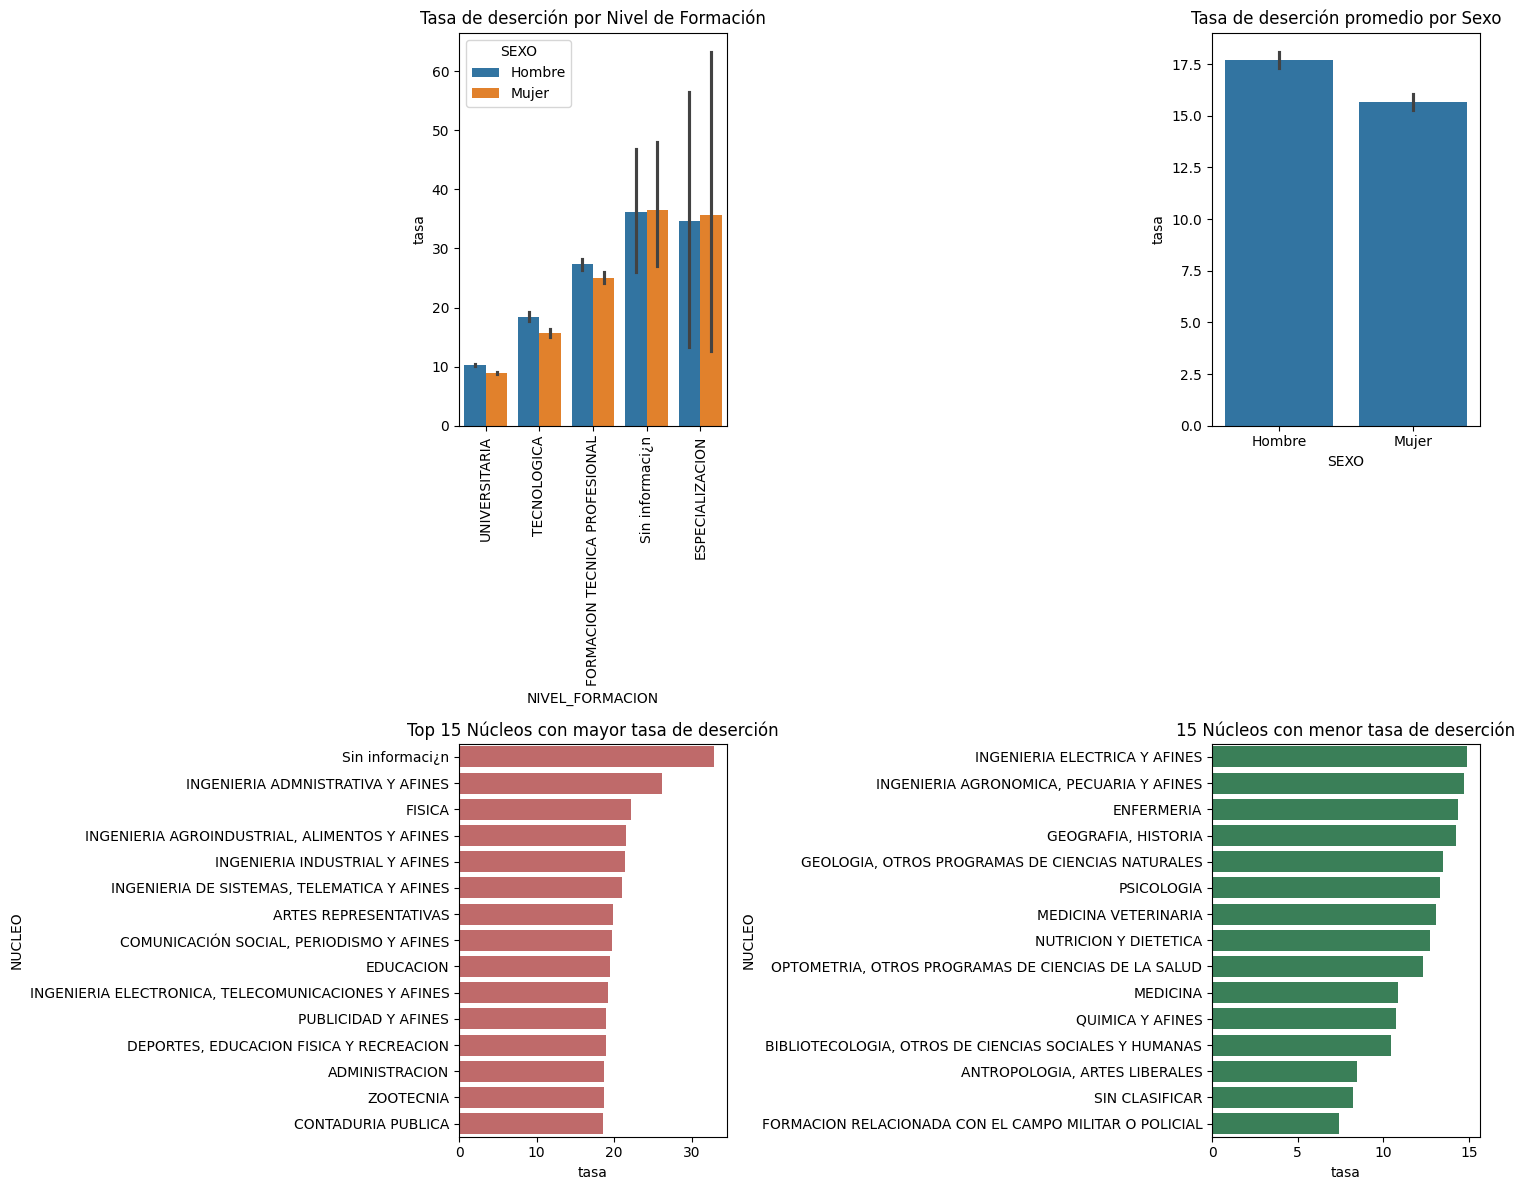

In [9]:
pivot = pivot.sort_values('periodo')
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

sbn.barplot(data=pivot, x='NIVEL_FORMACION', y='tasa', hue='SEXO', ax=axs[0,0])
axs[0,0].tick_params(axis='x', rotation=90)
axs[0,0].set_title('Tasa de deserción por Nivel de Formación')

sbn.barplot(data=pivot, x='SEXO', y='tasa', ax=axs[0,1])
axs[0,1].set_title('Tasa de deserción promedio por Sexo')

ranking_nucleo = pivot.groupby('NUCLEO')['tasa'].mean().sort_values(ascending=False)

top15 = ranking_nucleo.head(15)
sbn.barplot(x=top15.values, y=top15.index, ax=axs[1,0], color='indianred')
axs[1,0].set_title('Top 15 Núcleos con mayor tasa de deserción')
axs[1,0].set_xlabel('tasa')

bottom15 = ranking_nucleo.tail(15)
sbn.barplot(x=bottom15.values, y=bottom15.index, ax=axs[1,1], color='seagreen')
axs[1,1].set_title('15 Núcleos con menor tasa de deserción')
axs[1,1].set_xlabel('tasa')

plt.tight_layout()
plt.show()

Evolución de la tasa de deserción por Nivel de Formación a través del tiempo

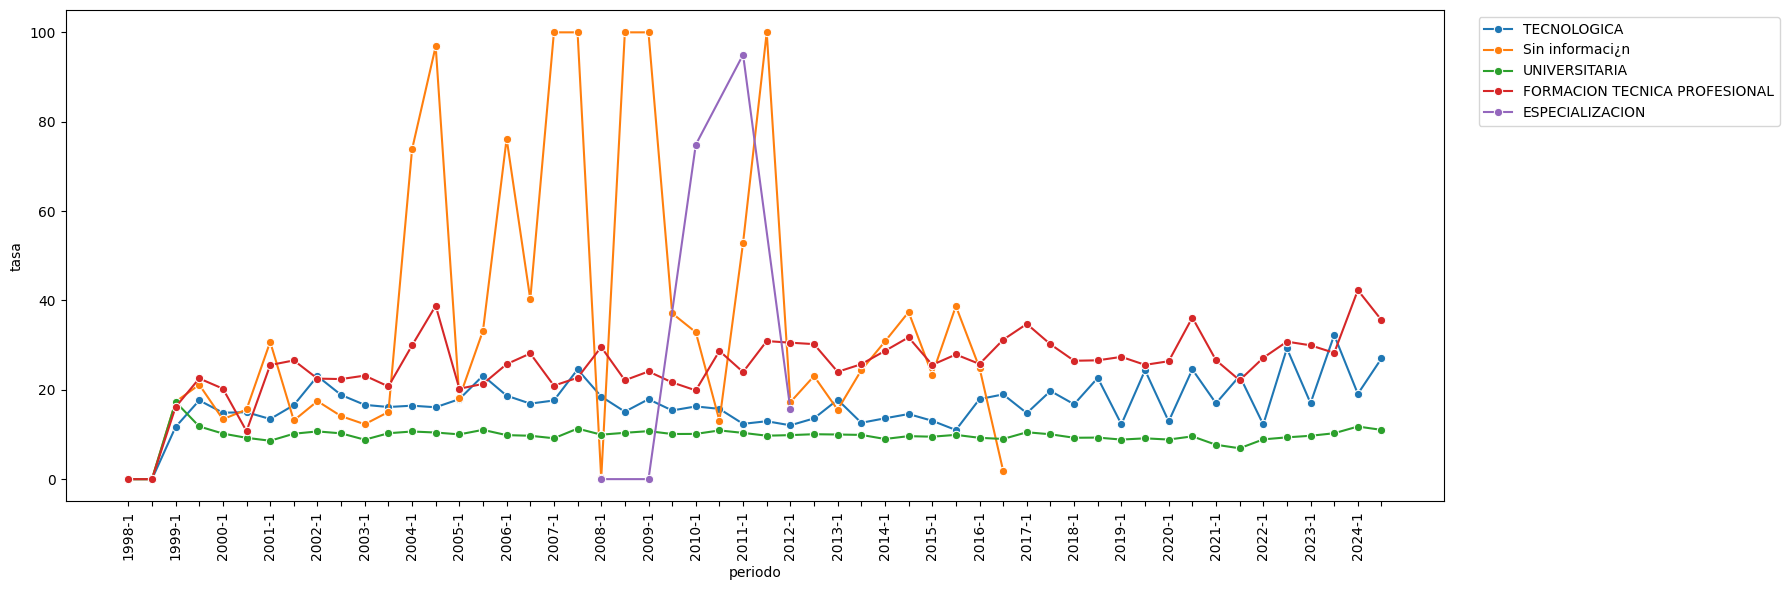

In [10]:
f = pivot.groupby(['NIVEL_FORMACION','periodo'])['tasa'].mean().reset_index()

# Forzamos orden cronológico explícito: NIVEL_FORMACION no aparece desde el
# mismo período para todas las categorías, y lineplot ordena el eje X por
# orden de aparición en los datos (no alfabético) si no se lo indicamos.
orden_periodos = sorted(f['periodo'].unique())
f['periodo'] = pd.Categorical(f['periodo'], categories=orden_periodos, ordered=True)
f = f.sort_values('periodo')

plt.figure(figsize=(18,6))
ax = sbn.lineplot(data=f, x='periodo', y='tasa', hue='NIVEL_FORMACION', marker='o')

# Mostrar solo 1 de cada N etiquetas en X
for i, label in enumerate(ax.get_xticklabels()):
    if i % 2 != 0:
        label.set_visible(False)

plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()